# Setup & Styling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set  Style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'sans-serif',
    'figure.dpi': 150,      # Good for inline viewing
    'savefig.dpi': 300,     # High-res for saving
    'axes.labelsize': 12,
    'axes.titlesize': 14
})

os.makedirs("paper_figures", exist_ok=True)
print(" Libraries loaded  styling applied.")

 Libraries loaded  styling applied.


# Performance Matrix Table

In [4]:
# Data from my terminal output
data_closed = {
    "Method": ["Landmark-MLP", "TinyCNN (ROI)", "Proposed (EmbedNet)"],
    "Accuracy": [0.9712, 0.4808, 0.9904],
    "Macro F1": [0.9696, 0.4543, 0.9881],
    "AUROC (Open-Set)": [0.7747, np.nan, 0.9728], # CNN skipped open-set
    "Latency (ms)": [0.035, 0.527, 0.042],
    "Parameters": [19268, 1203876, 21088]
}

df_main = pd.DataFrame(data_closed)

# Display a beautifully formatted table
display(df_main.style.format({
    "Accuracy": "{:.2%}",
    "Macro F1": "{:.2%}",
    "AUROC (Open-Set)": "{:.4f}",
    "Latency (ms)": "{:.3f}",
    "Parameters": "{:,}"
}).background_gradient(subset=["Accuracy", "AUROC (Open-Set)"], cmap="Greens") \
  .highlight_min(subset=["Latency (ms)", "Parameters"], color="blue"))

,Method,Accuracy,Macro F1,AUROC (Open-Set),Latency (ms),Parameters
0,Landmark-MLP,97.12%,96.96%,0.7747,0.035,"19,268"
1,TinyCNN (ROI),48.08%,45.43%,nan,0.527,"1,203,876"
2,Proposed (EmbedNet),99.04%,98.81%,0.9728,0.042,"21,088"


# Core matrix Benchmark

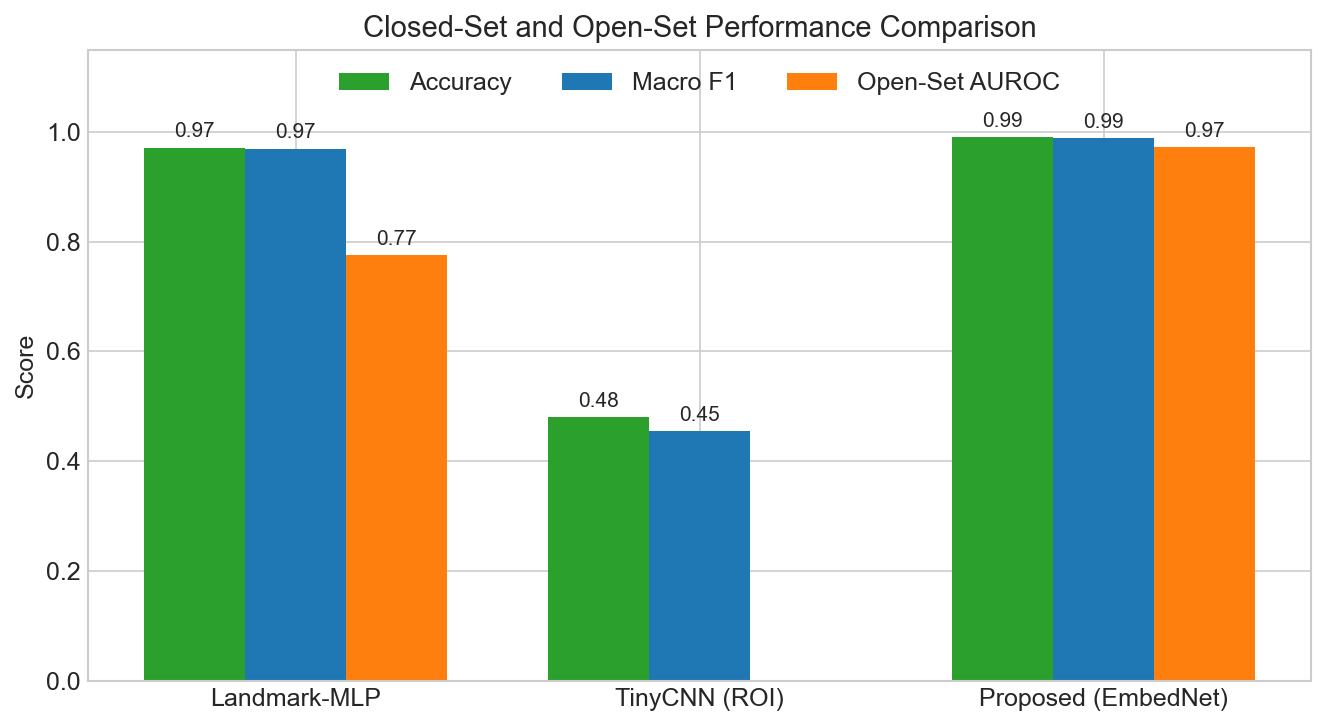

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_main["Method"]))
width = 0.25

rects1 = ax.bar(x - width, df_main["Accuracy"], width, label='Accuracy', color='#2ca02c')
rects2 = ax.bar(x, df_main["Macro F1"], width, label='Macro F1', color='#1f77b4')
# Fill NaNs with 0 just for plotting the CNN gap
rects3 = ax.bar(x + width, df_main["AUROC (Open-Set)"].fillna(0), width, label='Open-Set AUROC', color='#ff7f0e')

ax.set_ylabel('Score')
ax.set_title('Closed-Set and Open-Set Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(df_main["Method"])
ax.set_ylim(0, 1.15)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=3)

# Add value labels
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        if height > 0:
            ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('paper_figures/Fig1_Metrics.png')
plt.show()

# Robustness Drop

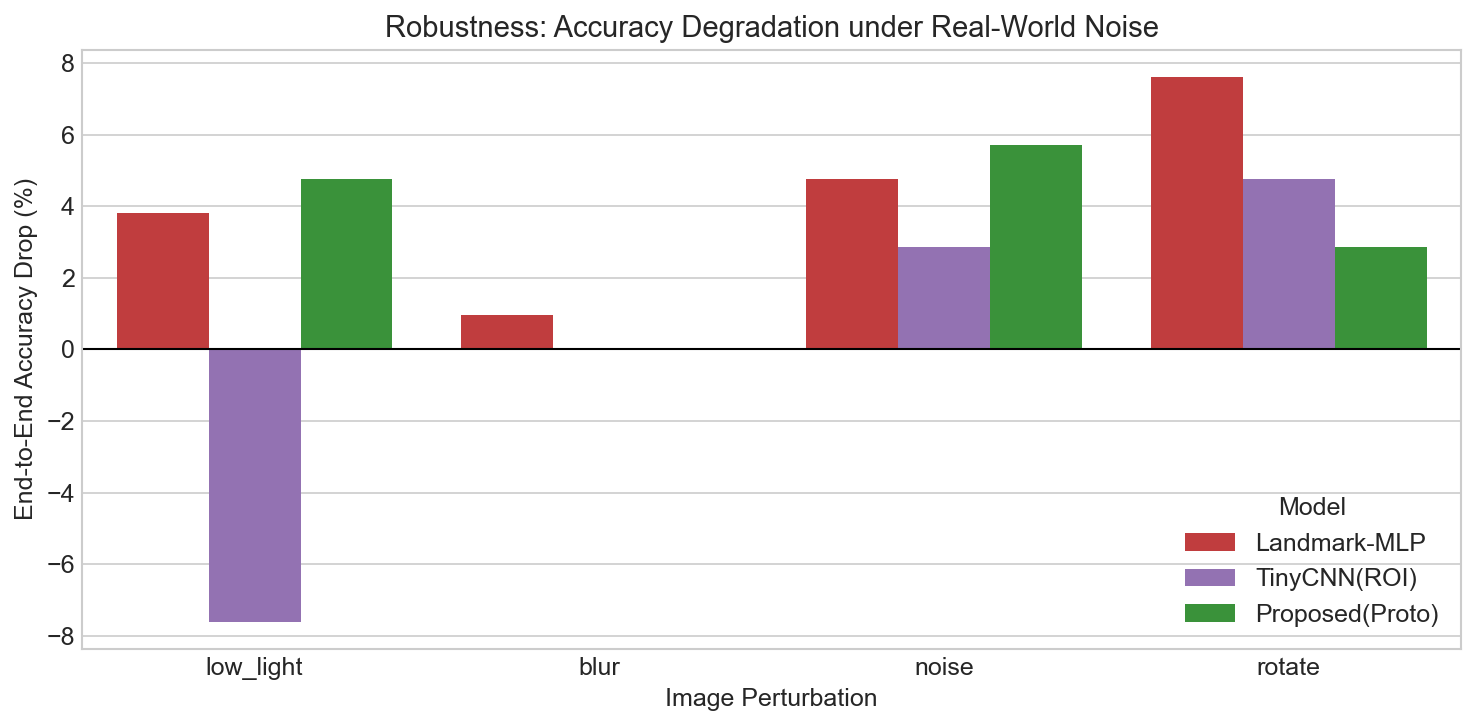

In [7]:
# Load your robustness results
df_rob = pd.read_csv("artifacts/robustness_results.csv")

# Filter out the "clean" run since we want to plot the drop
df_drop = df_rob[df_rob["perturbation"] != "clean"].copy()

# We need the clean scores to calculate the drop
clean_scores = df_rob[df_rob["perturbation"] == "clean"].set_index("method")["e2e_acc"].to_dict()
df_drop["drop_percentage"] = df_drop.apply(lambda row: (clean_scores[row["method"]] - row["e2e_acc"]) * 100, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=df_drop, x="perturbation", y="drop_percentage", hue="method", palette=["#d62728", "#9467bd", "#2ca02c"])

ax.set_ylabel('End-to-End Accuracy Drop (%)')
ax.set_xlabel('Image Perturbation')
ax.set_title('Robustness: Accuracy Degradation under Real-World Noise')
ax.axhline(0, color='black', linewidth=1)
plt.legend(title="Model")

plt.tight_layout()
plt.savefig('paper_figures/Fig2_Robustness.png')
plt.show()

# Computational Efficiency (Log Scale)

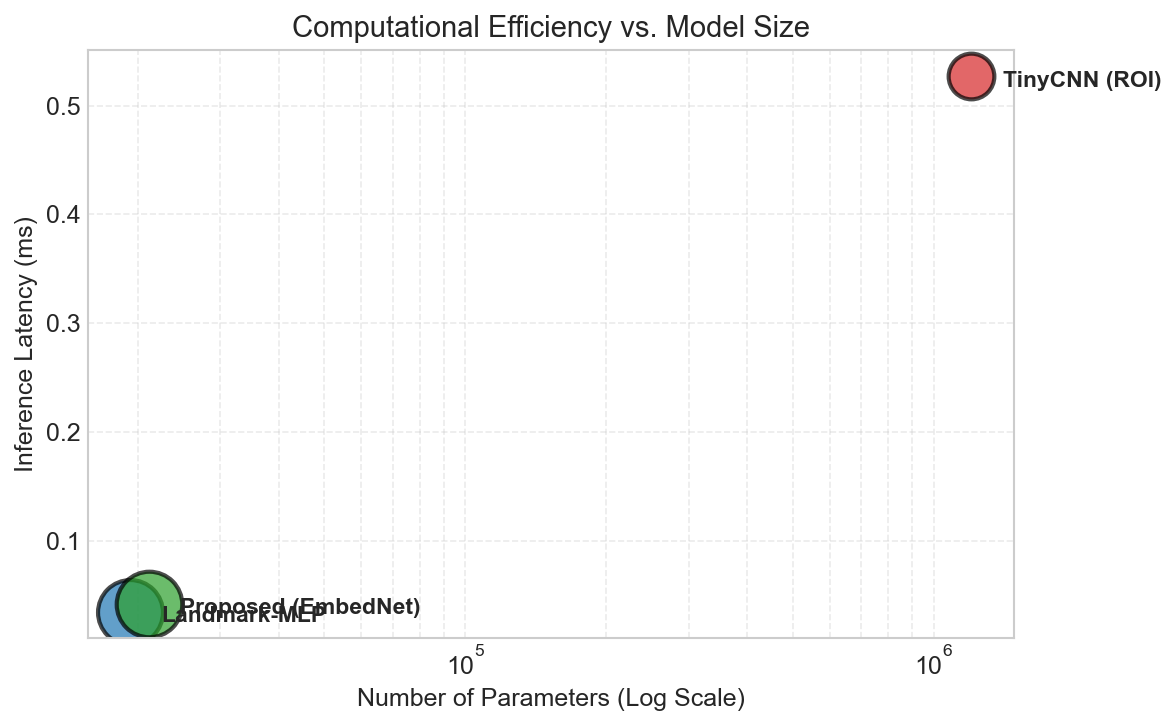

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot: Params (X) vs Latency (Y), size is Accuracy
colors = ['#1f77b4', '#d62728', '#2ca02c']
for i, row in df_main.iterrows():
    ax.scatter(row["Parameters"], row["Latency (ms)"], 
               s=row["Accuracy"] * 1000, color=colors[i], alpha=0.7, edgecolors='black', linewidth=2, label=row["Method"])
    
    # Label the bubbles
    ax.annotate(row["Method"], (row["Parameters"], row["Latency (ms)"]), 
                xytext=(15, -5), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xscale('log')
ax.set_xlabel('Number of Parameters (Log Scale)')
ax.set_ylabel('Inference Latency (ms)')
ax.set_title('Computational Efficiency vs. Model Size')
plt.grid(True, which="both", ls="--", alpha=0.4)

plt.tight_layout()
plt.savefig('paper_figures/Fig3_Efficiency.png')
plt.show()

# Visualizing The Confusing Matrix

In [2]:
import numpy as np
import torch
from sklearn.metrics import confusion_matrix
from models import LandmarkMLP, EmbedNet, TinyCNN

ds = np.load("artifacts/dataset.npz", allow_pickle=True)
device = "cpu"
C = len(ds["classes"])

# Load test data
Xte_lm = torch.from_numpy(ds["Xte_lm"]).to(device)
yte = ds["yte"]
Xte_roi = (torch.from_numpy(ds["Xte_roi"]).permute(0,3,1,2).float()/255.0).to(device)

# 1. Landmark-MLP Predictions
ck_lm = torch.load("artifacts/landmark_mlp.pt", map_location=device)
lm = LandmarkMLP(Xte_lm.shape[1], C).to(device)
lm.load_state_dict(ck_lm["state_dict"])
lm.eval()
with torch.no_grad(): preds_lm = torch.argmax(lm(Xte_lm), dim=1).numpy()

# 2. TinyCNN Predictions
ck_cnn = torch.load("artifacts/tiny_cnn.pt", map_location=device)
cnn = TinyCNN(C).to(device)
cnn.load_state_dict(ck_cnn["state_dict"])
cnn.eval()
with torch.no_grad(): preds_cnn = torch.argmax(cnn(Xte_roi), dim=1).numpy()

# 3. Proposed (Proto) Predictions
ck_emb = torch.load("artifacts/embednet.pt", map_location=device)
emb = EmbedNet(Xte_lm.shape[1], ck_emb["emb_dim"]).to(device)
emb.load_state_dict(ck_emb["emb"])
emb.eval()
with torch.no_grad():
    Ztr = emb(torch.from_numpy(ds["Xtr_lm"])).numpy()
    Zte = emb(Xte_lm).numpy()
    
protos = np.stack([Ztr[ds["ytr"] == c].mean(axis=0) for c in range(C)])
protos = protos / (np.linalg.norm(protos, axis=1, keepdims=True) + 1e-8)
preds_prop = np.argmax(Zte @ protos.T, axis=1)

# Calculate and Save Confusion Matrices
np.savez("artifacts/confusion_matrices.npz", 
         cm_lm=confusion_matrix(yte, preds_lm),
         cm_cnn=confusion_matrix(yte, preds_cnn),
         cm_prop=confusion_matrix(yte, preds_prop),
         classes=ds["classes"])
         
print(" Successfully generated artifacts/confusion_matrices.npz")

 Successfully generated artifacts/confusion_matrices.npz


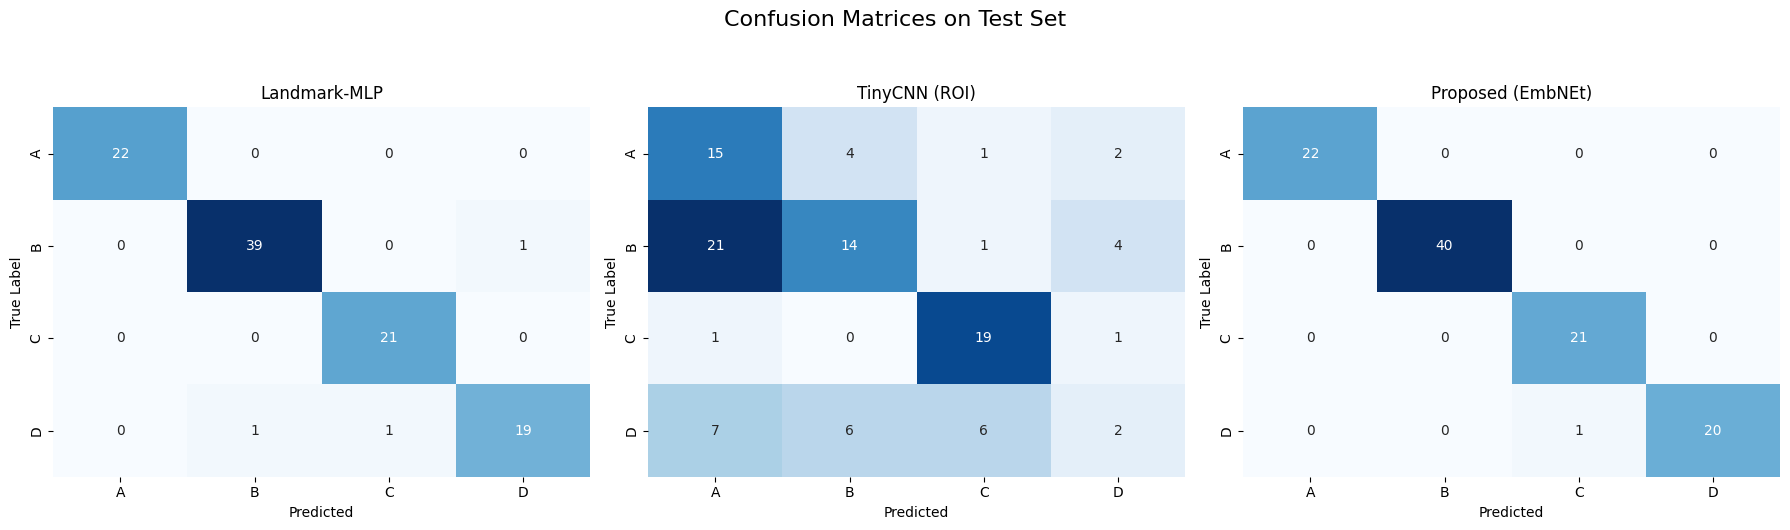

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm_data = np.load("artifacts/confusion_matrices.npz", allow_pickle=True)
classes = cm_data["classes"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [("Landmark-MLP", "cm_lm"), ("TinyCNN (ROI)", "cm_cnn"), ("Proposed (EmbNEt)", "cm_prop")]

for ax, (name, key) in zip(axes, models):
    cm = cm_data[key]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices on Test Set', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('paper_figures/Fig4_ConfusionMatrices.png')
plt.show()